# Decoded Plots

In [22]:
import sys
import importlib
import pandas as pd
from pathlib import Path

repo_src = None
repo_root = None
for base in [Path.cwd(), *Path.cwd().parents]:
    if (base / "src" / "plots" / "plot_helpers.py").exists():
        repo_src = base / "src" / "plots"
        repo_root = base
        break
    if (base / "plots" / "plot_helpers.py").exists():
        repo_src = base / "plots"
        repo_root = base.parent
        break
    if (base / "plot_helpers.py").exists():
        repo_src = base
        repo_root = base.parent.parent
        break

if repo_src is None or repo_root is None:
    raise FileNotFoundError("Could not locate plot_helpers.py")

if str(repo_src) not in sys.path:
    sys.path.insert(0, str(repo_src))

import plot_helpers

importlib.reload(plot_helpers)

paths = {
    "decoded": repo_root / "output" / "decoded.csv",
    "decoded_bpsk": repo_root / "output" / "decoded_bpsk.csv",
    "decoded_ecc_bpsk": repo_root / "output" / "decoded_ecc_bpsk.csv",
    "decoded_ecc_dbpsk": repo_root / "output" / "decoded_ecc_dbpsk.csv",
    "decoded_no_wa_dbpsk": repo_root / "output" / "encode_decode_no_wa_dbpsk.csv",
    "decoded_no_wa_bpsk": repo_root / "output" / "encode_decode_no_wa_bpsk.csv",
    "decoded_no_wa_dbpsk_4": repo_root / "output" / "encode_decode_no_wa_dbpsk_4.csv",
    "decoded_no_wa_bpsk_4": repo_root / "output" / "encode_decode_no_wa_bpsk_4.csv",
    "decoded_no_wa_dbpsk_8": repo_root / "output" / "encode_decode_no_wa_dbpsk_8.csv",
    "decoded_no_wa_bpsk_8": repo_root / "output" / "encode_decode_no_wa_bpsk_8.csv",
    "decoded_no_wa_bpsk_16": repo_root / "output" / "encode_decode_no_wa_bpsk_16.csv",
    "definitive_dbspk": repo_root / "output" / "260530_decoded_dbpsk_ecc.csv",
    "new_bpsk": repo_root / "output" / "zzz.csv",
    "new_bpsk1": repo_root / "output" / "zzz1.csv",
    "definitive_bspk": repo_root / "output" / "260530_decoded_bpsk_ecc.csv",
    "decoded_no_wa_backup": repo_root / "output" / "encode_decode_no_wa.csv.bak",
    "without_end_preamble": repo_root
    / "output"
    / "encode_decode_no_wa_no_end_preamble.csv",
}

df_first = pd.read_csv(
    paths["new_bpsk"],
)
df_second = pd.read_csv(
    paths["new_bpsk1"],
)

LABEL_FIRST: str = "new bpsk"
LABEL_SECOND: str = "bpsk old"

# Comparison between DBPSK and BPSK
From this comparison we can analyze what actually gets recognized in the file: is the preamble recognized? Is the decoded payload long enough?
These are the possible errors:
* `not-valid-preamble`: the preamble has not been recognized
* `check-error`: safety guards on the waveform properties
* `no-length-in-header`: the header is shorter than 16 bits, which are used to represent the number of bytes of the payload
* `paylod-too-short`: the payload is shorter than the number of bytes that are in the header

If there is no error, the status is `valid-preamble`.

In [23]:
from plot_helpers import print_decode_status, print_error_comparison

print(f"{LABEL_FIRST}:")
print_decode_status(df_first)
print()
print(f"{LABEL_SECOND}:")
print_decode_status(df_second)
print()
print_error_comparison(
    df_first,
    df_second,
    LABEL_FIRST,
    LABEL_SECOND,
)

new bpsk:
valid preambles: 260
not valid: 191
errors: 49
types of error: ['unsupported-header-version', 'paylod-too-short', 'unsupported-ecc-scheme']

bpsk old:
valid preambles: 260
not valid: 191
errors: 49
types of error: ['unsupported-header-version', 'paylod-too-short', 'unsupported-ecc-scheme']

Mean error new bpsk: 0.849
Mean error bpsk old: 0.849
Variance error new bpsk: 0.0784
Variance error bpsk old: 0.0784

new bpsk is better than bpsk old: 0, 0.0%
new bpsk is equal to bpsk old: 500, 100.0%
new bpsk is worse than bpsk old: 0, 0.0%
Mean improvement: nan
Improvement variance: nan
Mean worsening: nan
Worsening variance: nan


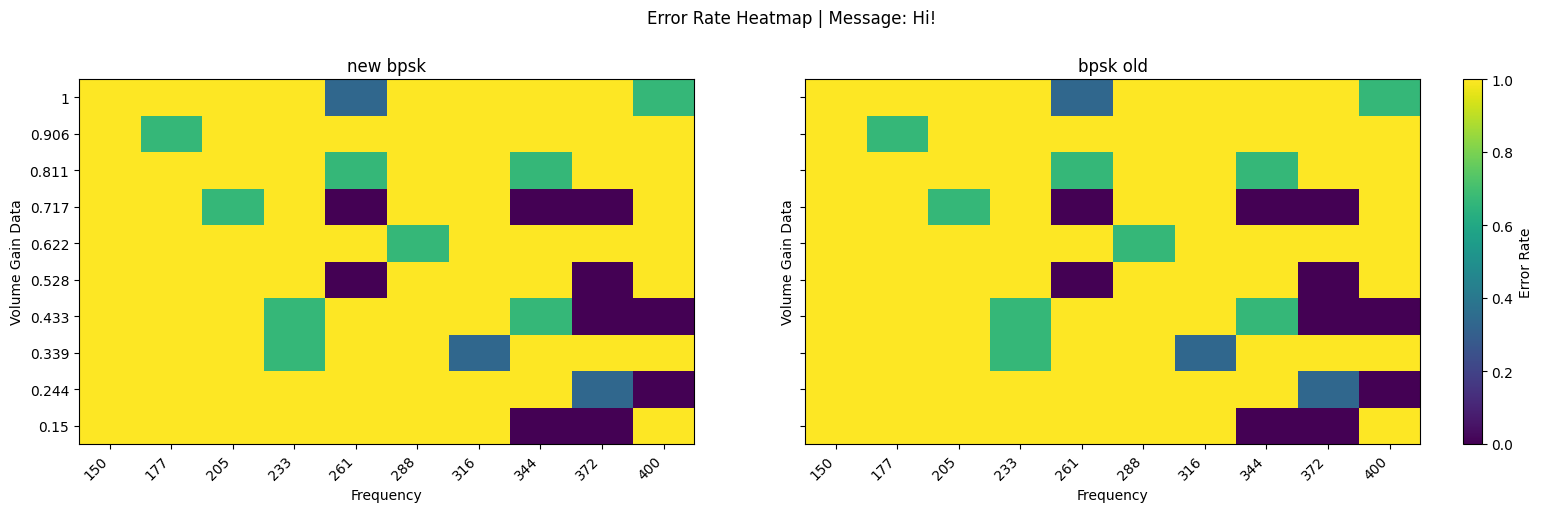

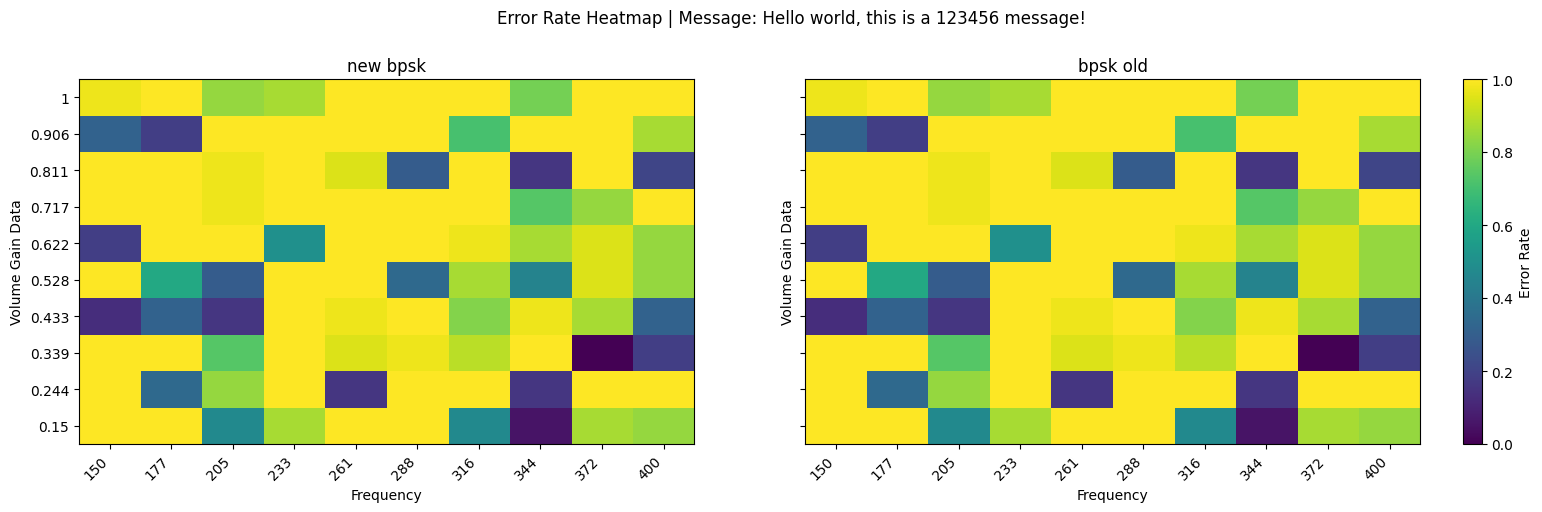

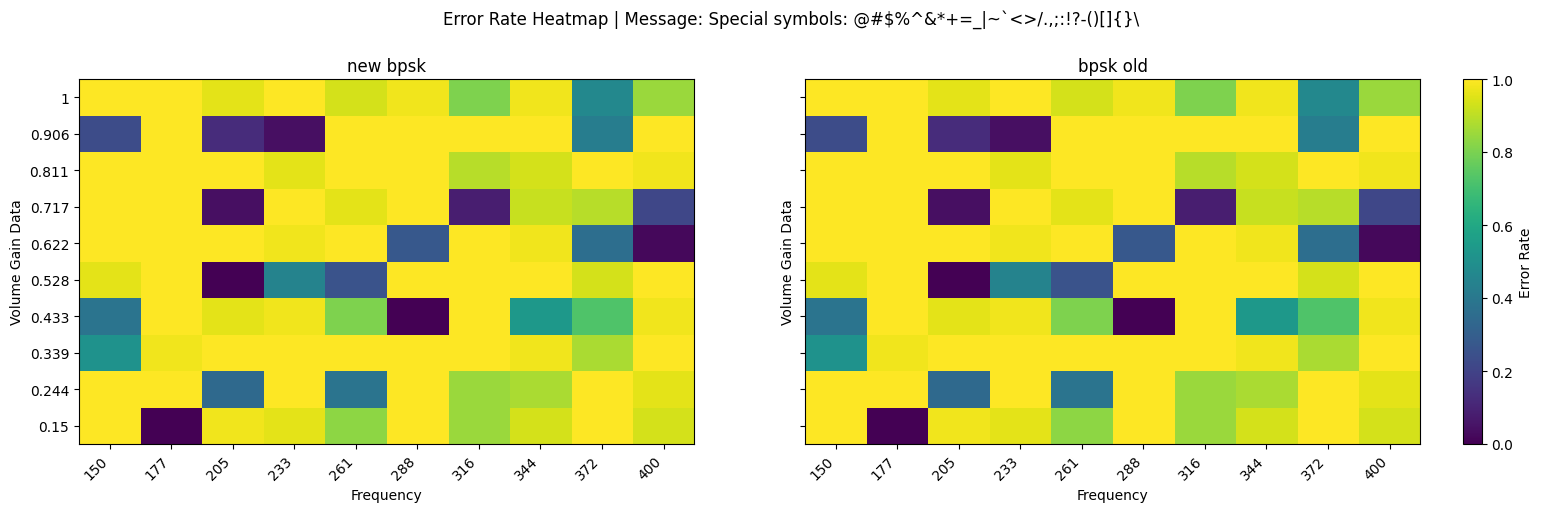

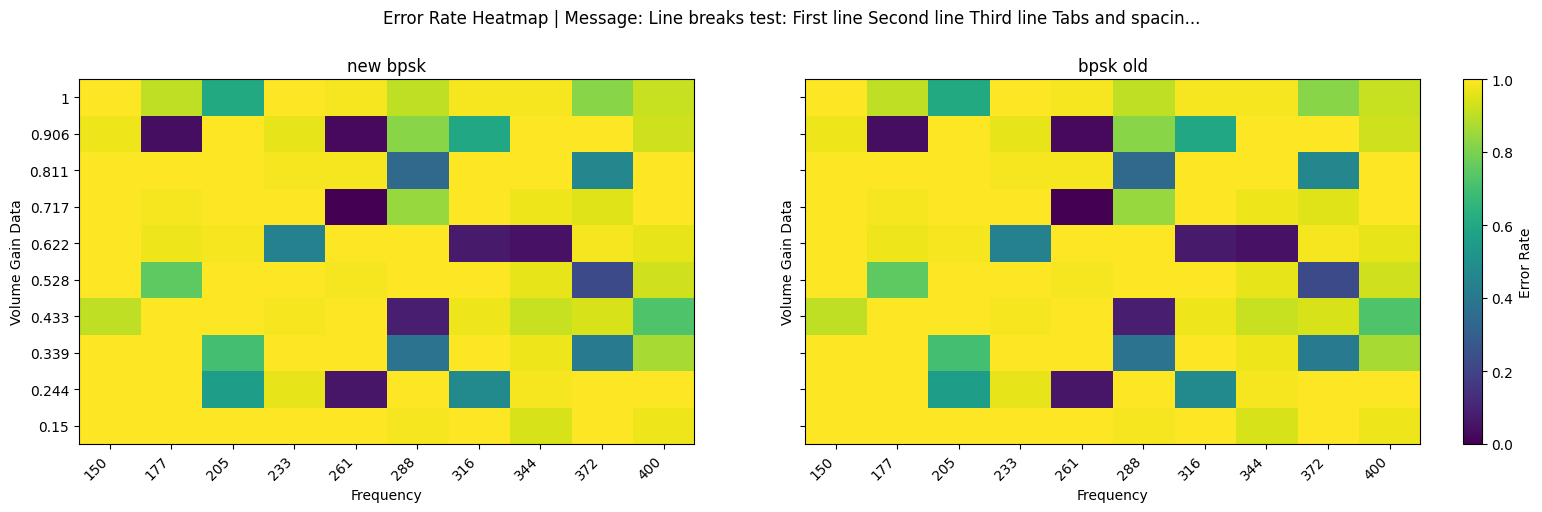

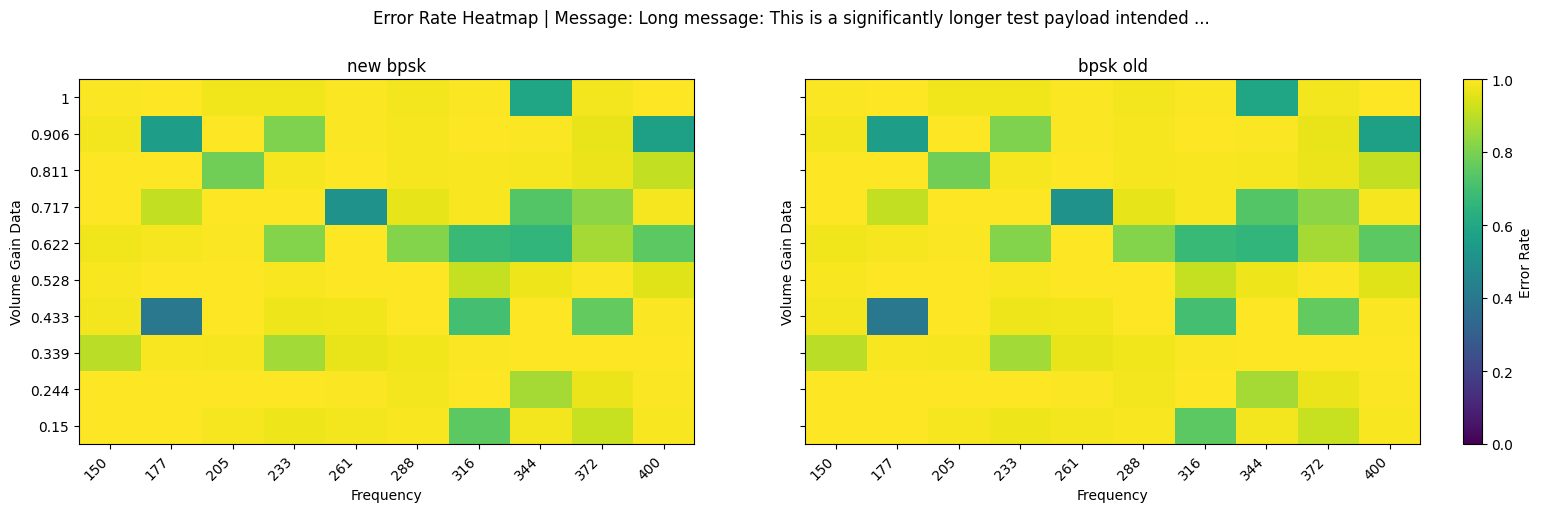

In [24]:
from plot_helpers import plot_error_rate_heatmaps_by_message_comparison

plot_error_rate_heatmaps_by_message_comparison(
    df_first,
    df_second,
    label_a=LABEL_FIRST,
    label_b=LABEL_SECOND,
)

## Error Rate vs Frequency (Comparison per Message)
Each figure is split into two columns for direct comparison between actual and best-case runs.

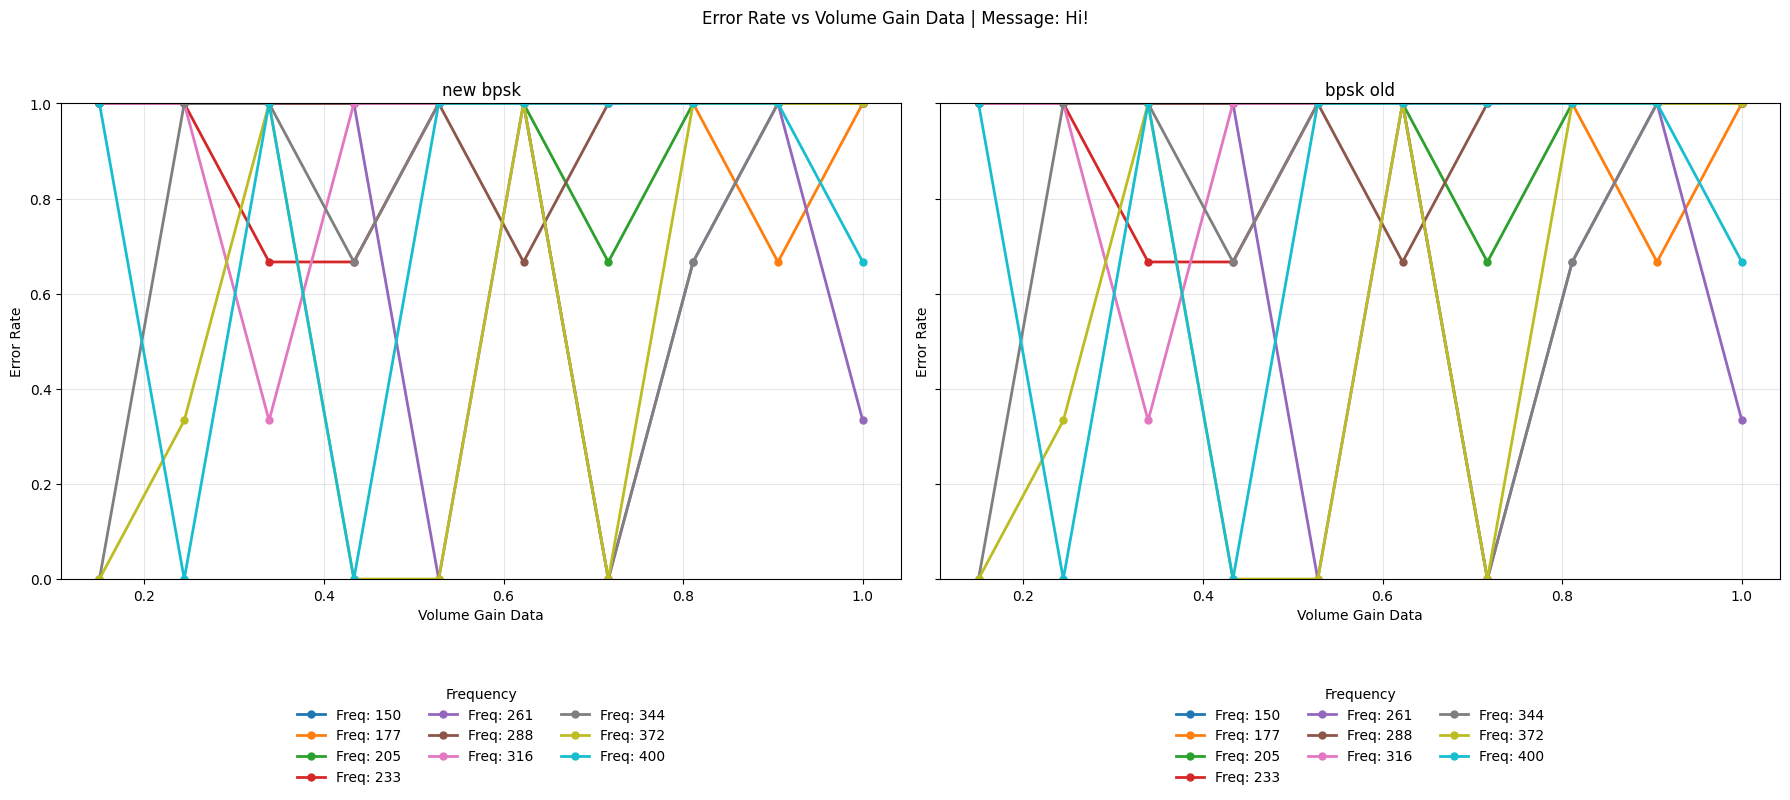

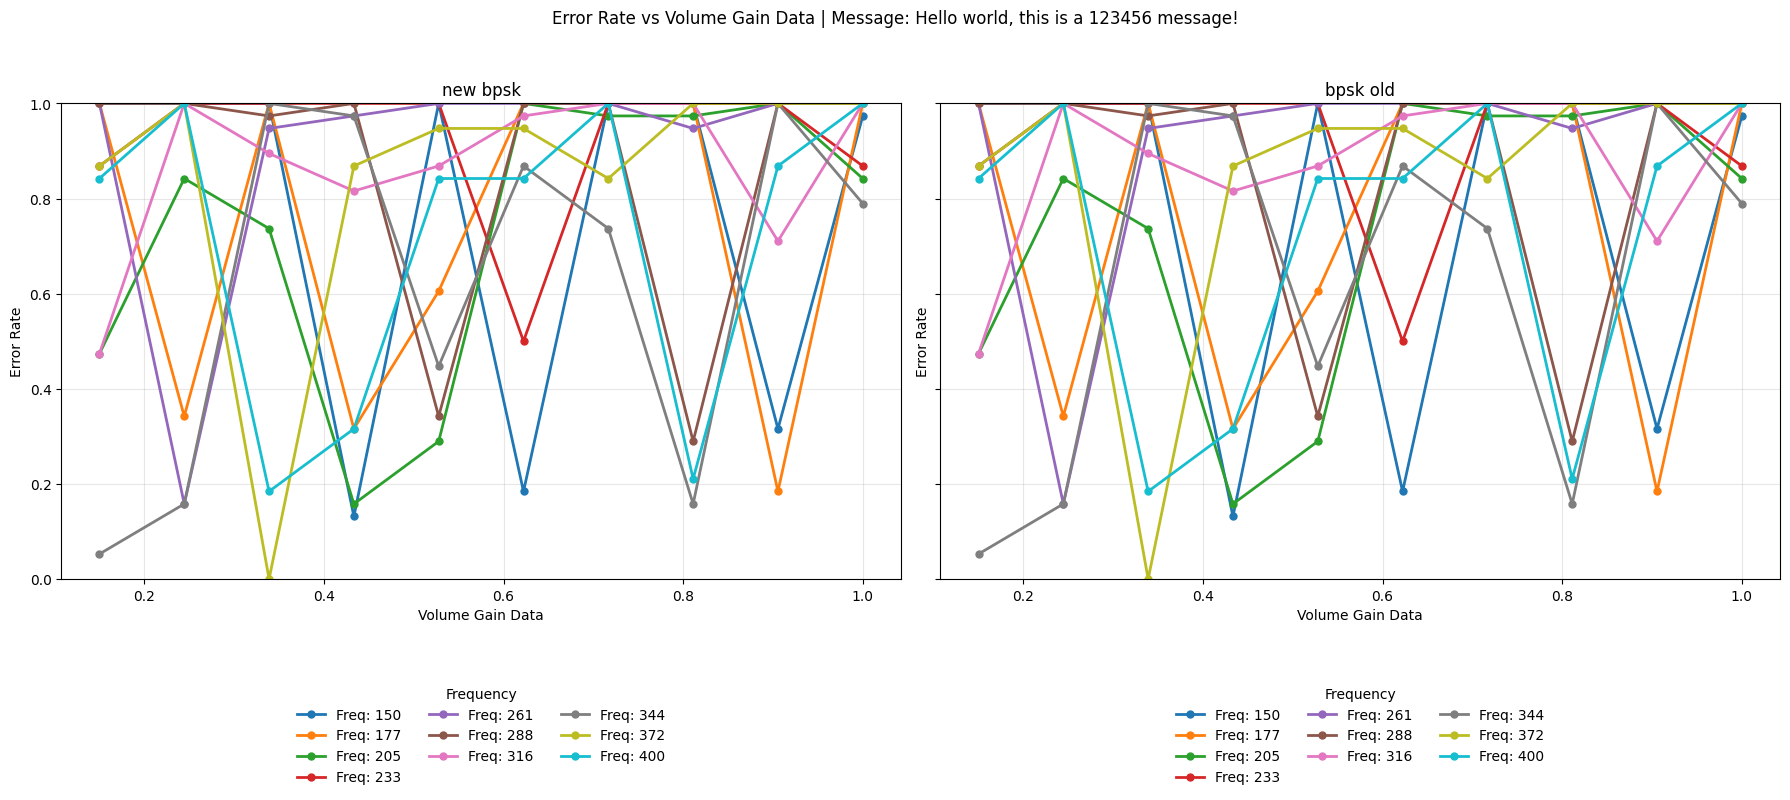

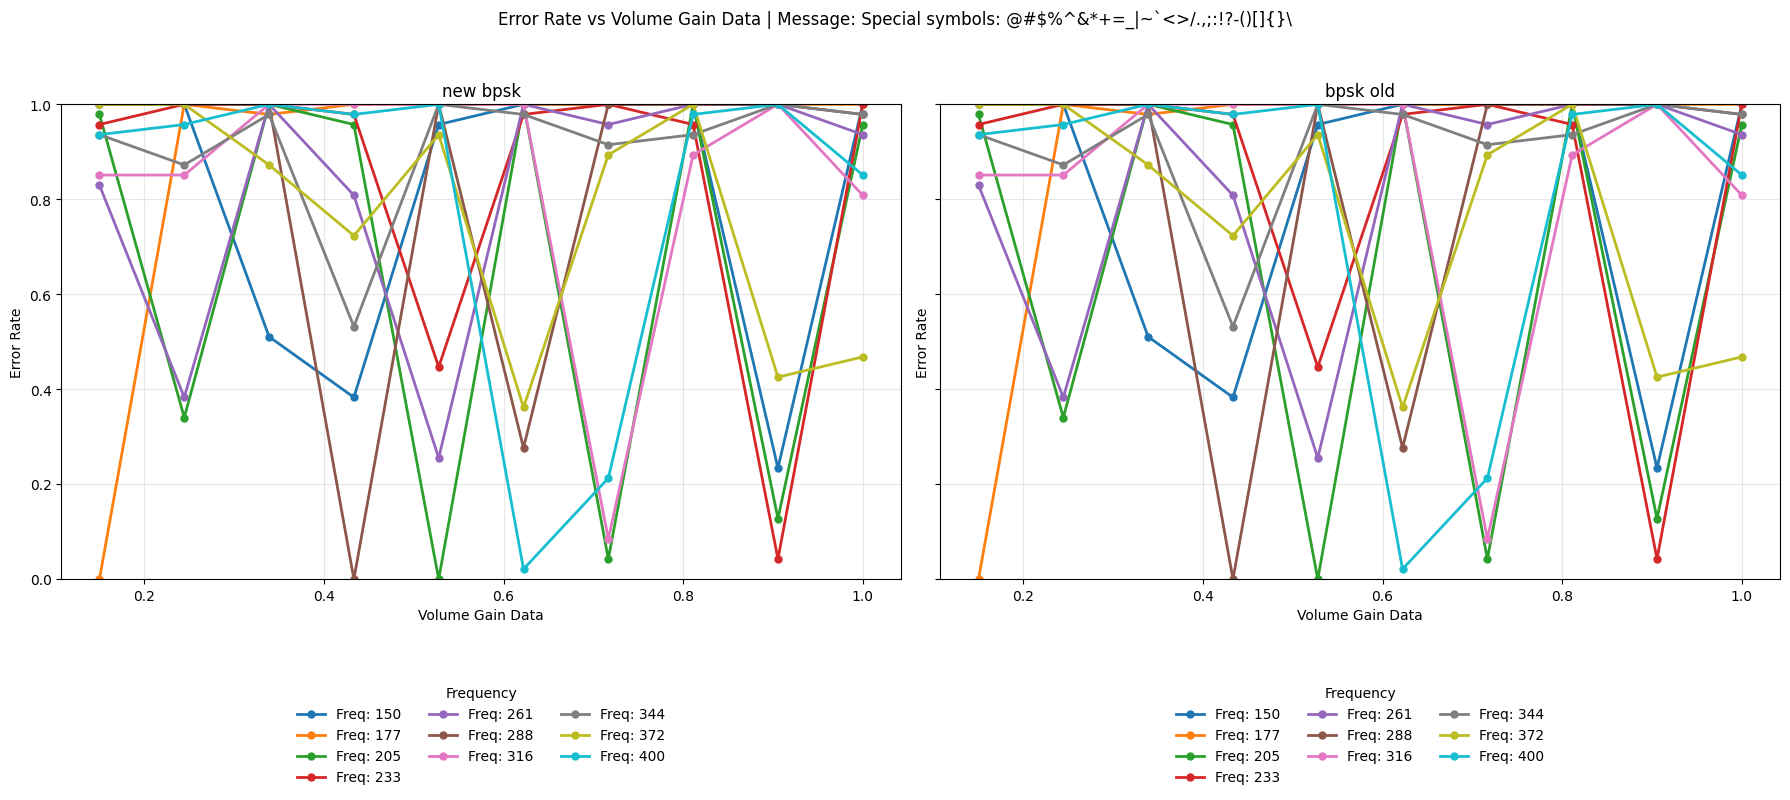

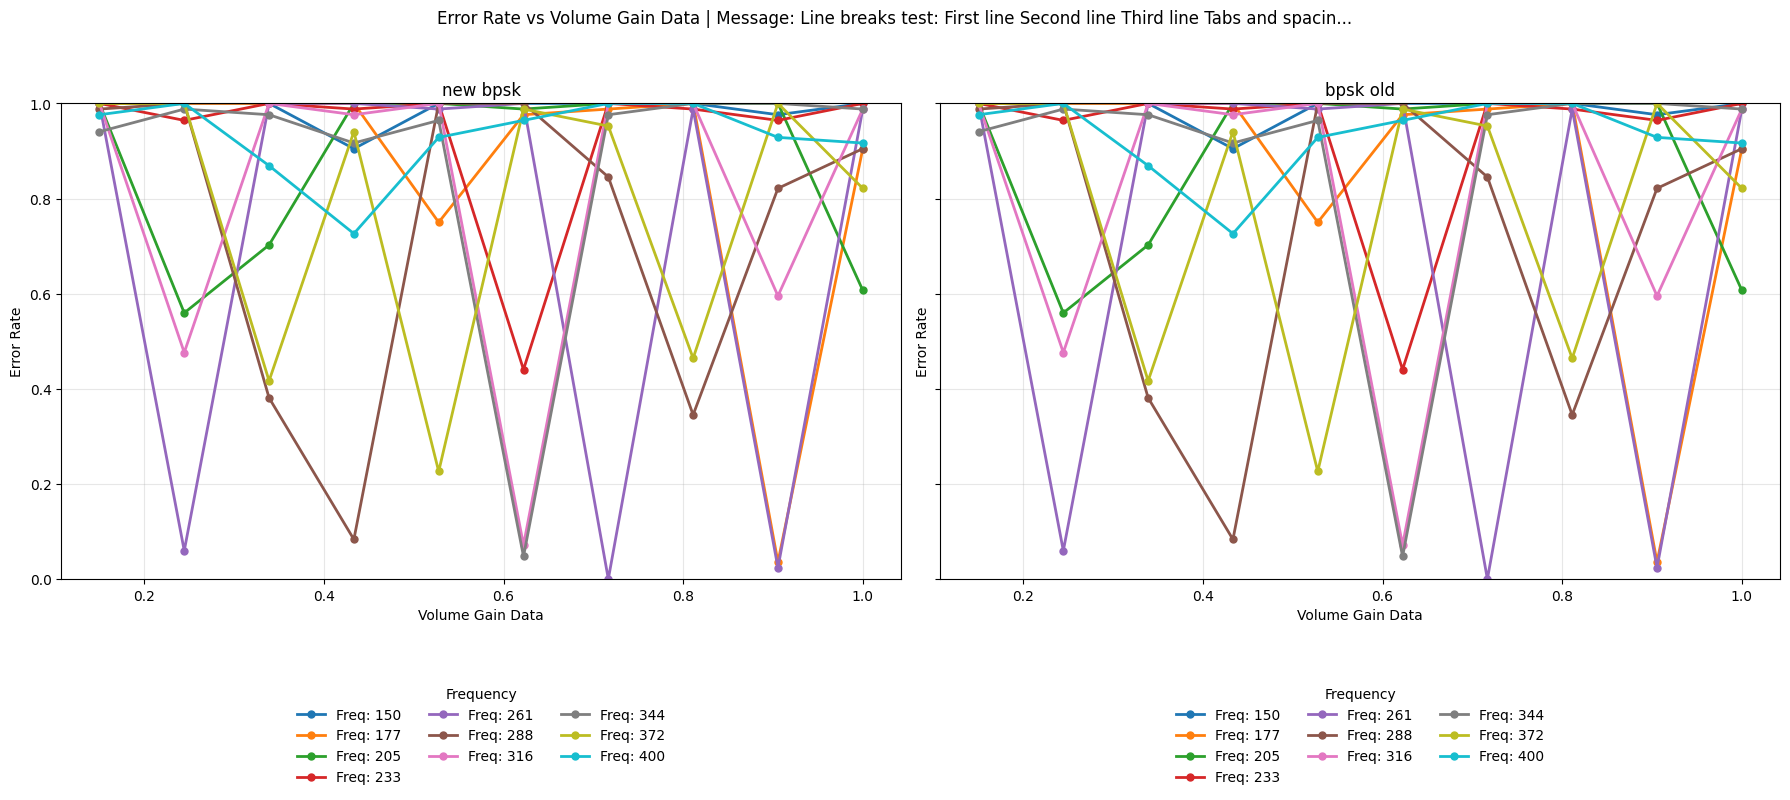

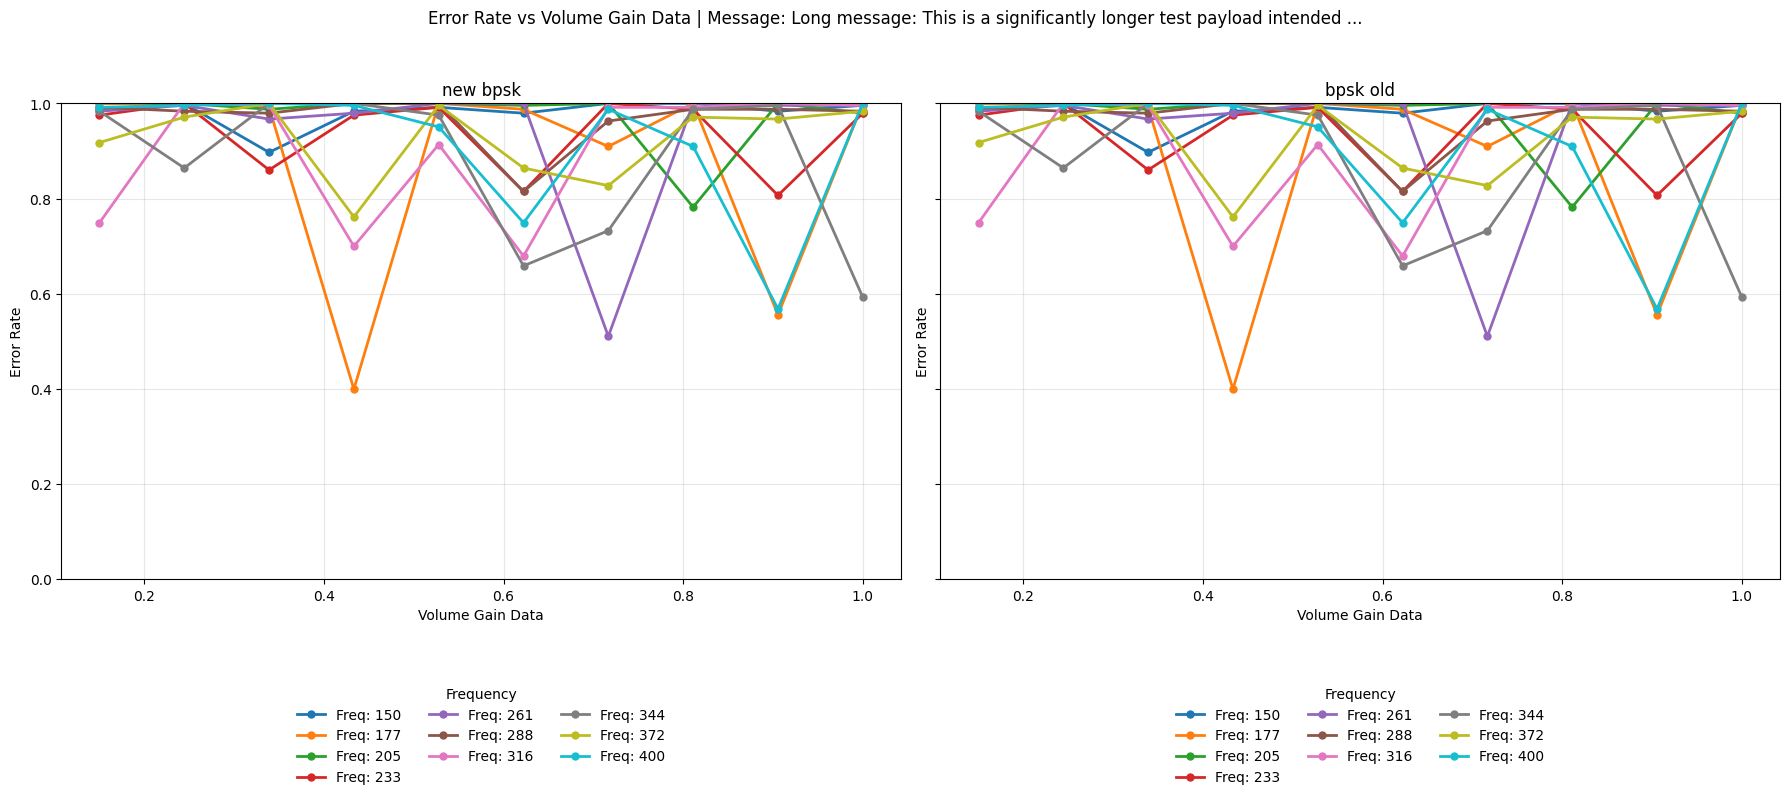

In [25]:
from plot_helpers import plot_error_rate_vs_frequency_by_message_comparison

plot_error_rate_vs_frequency_by_message_comparison(
    df_first,
    df_second,
    label_a=LABEL_FIRST,
    label_b=LABEL_SECOND,
)

## Error Rate Variance by Frequency (All Volume Gain Data Values, Comparison)
This section generates one comparison figure per available `volume_gain_data` value.
Each figure has:
- Column A: `csv_path`
- Column B: `no_audio_compression`
Violin plots are used by default and automatically fall back to box plots when groups are sparse.

Generating 10 comparison plots (one per volume_gain_data).


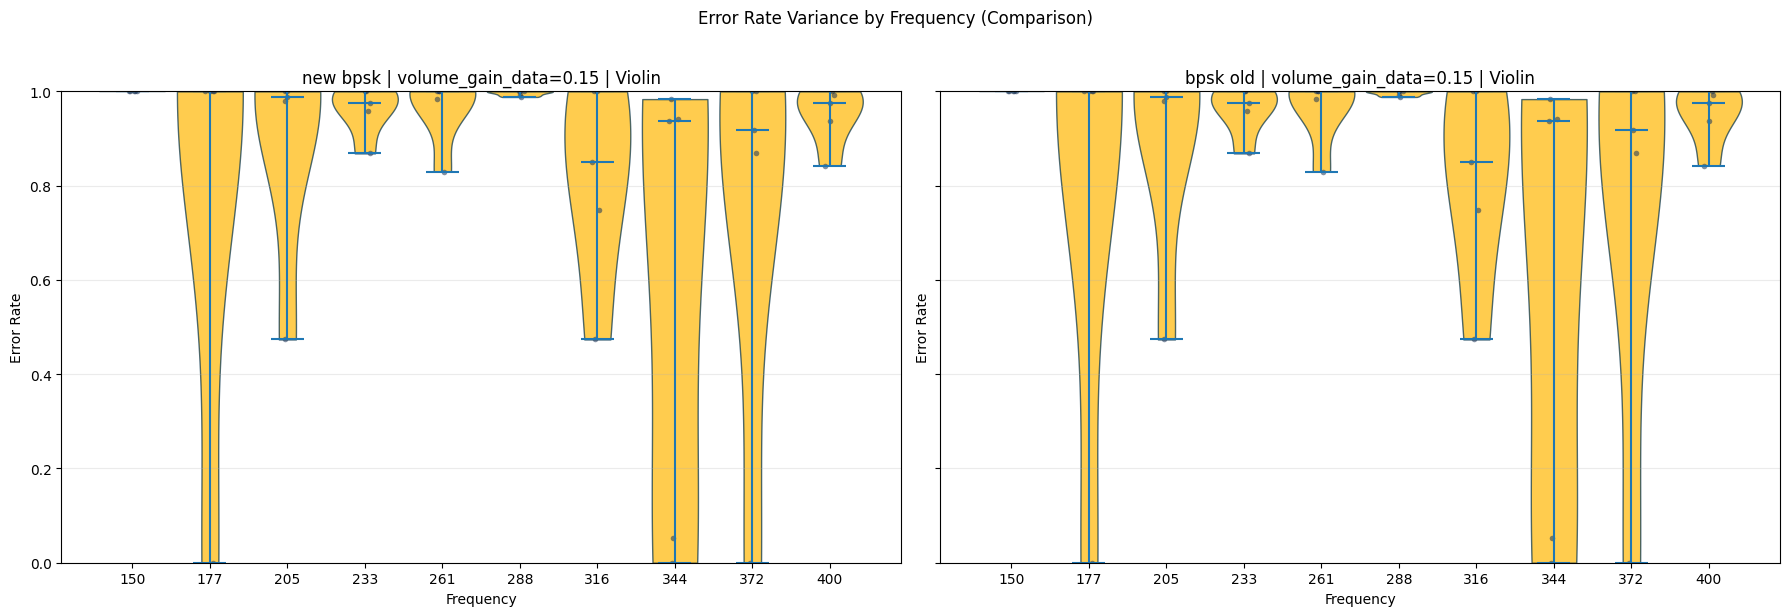

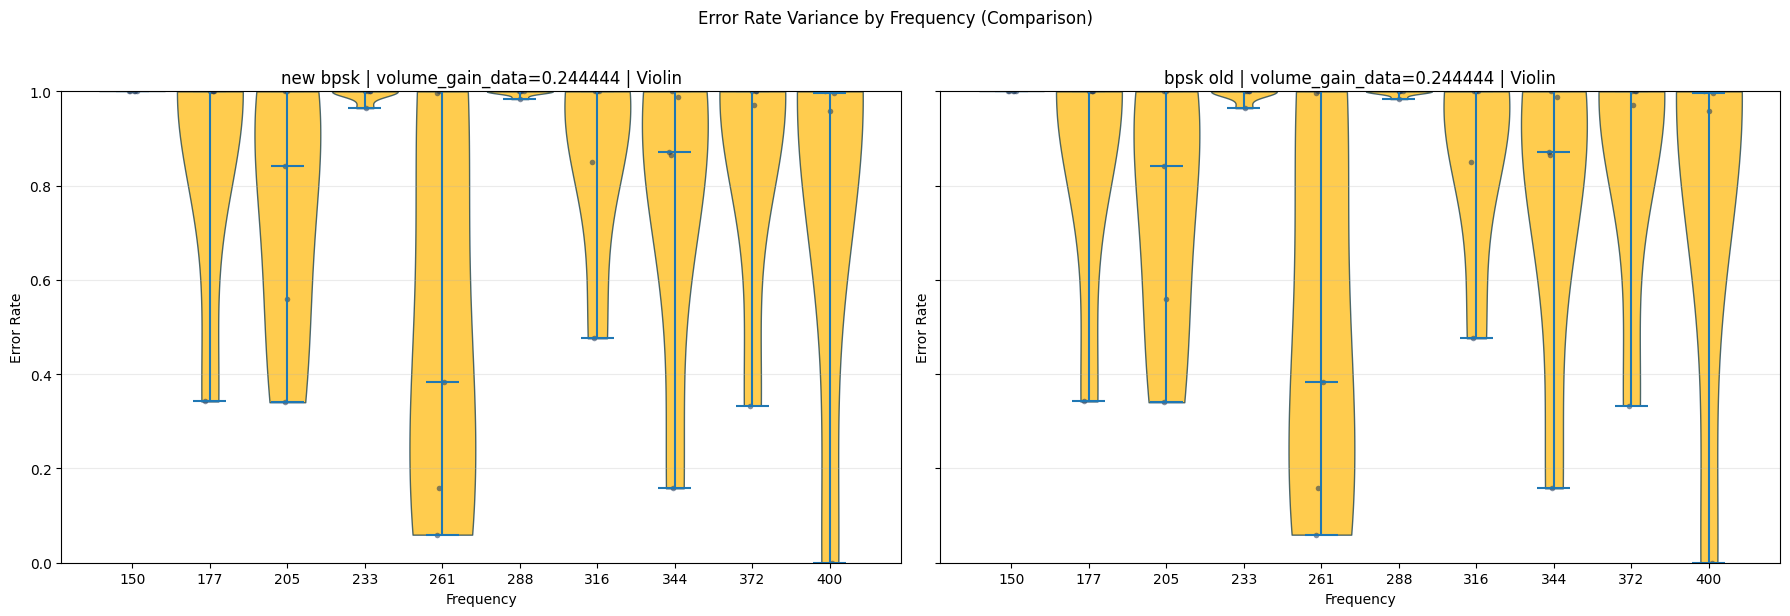

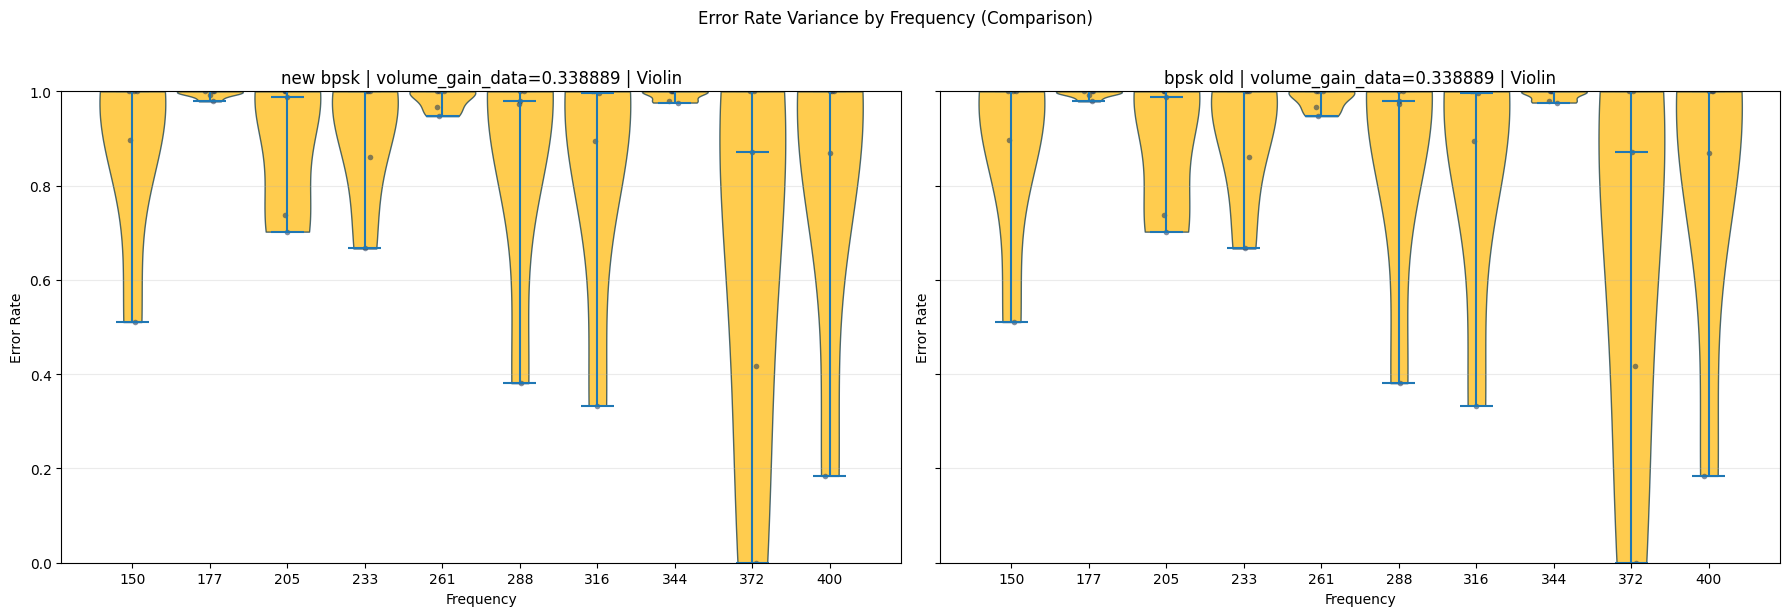

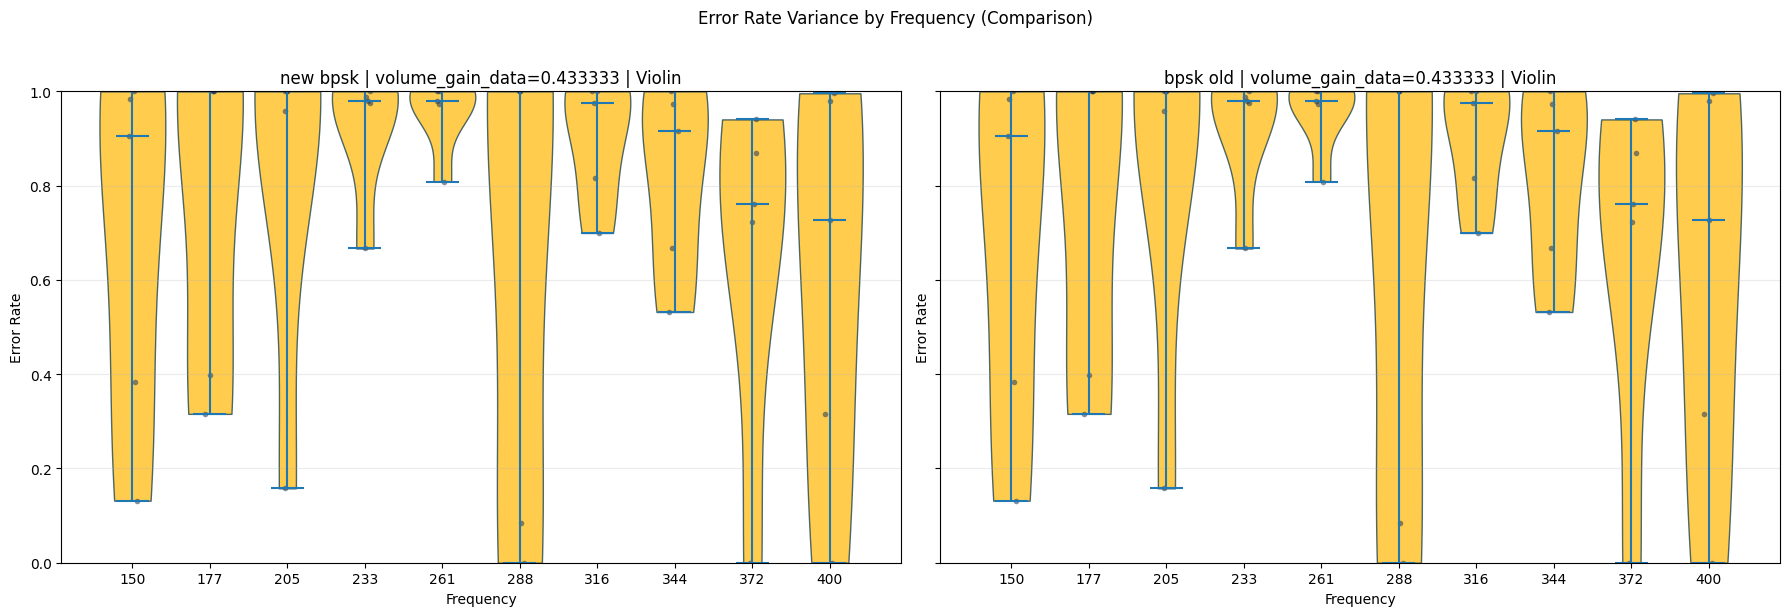

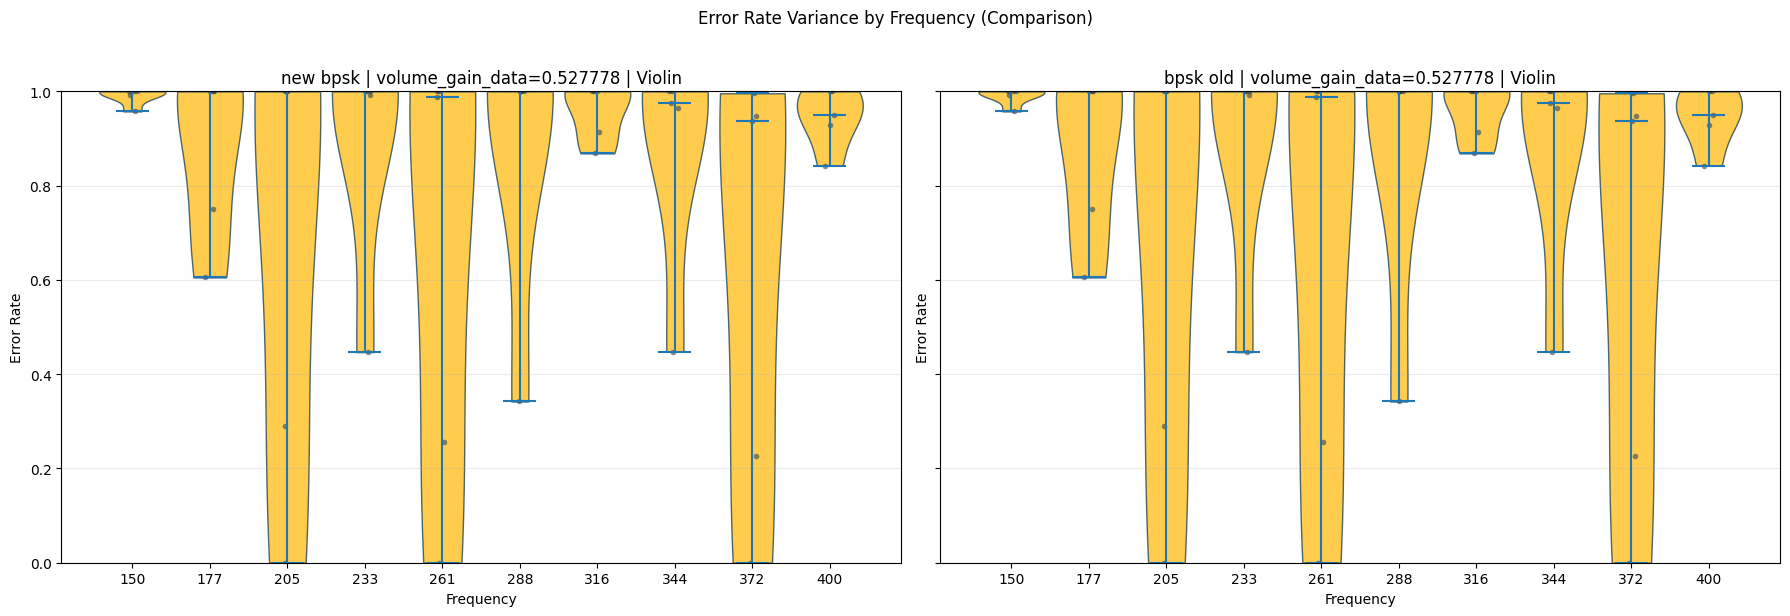

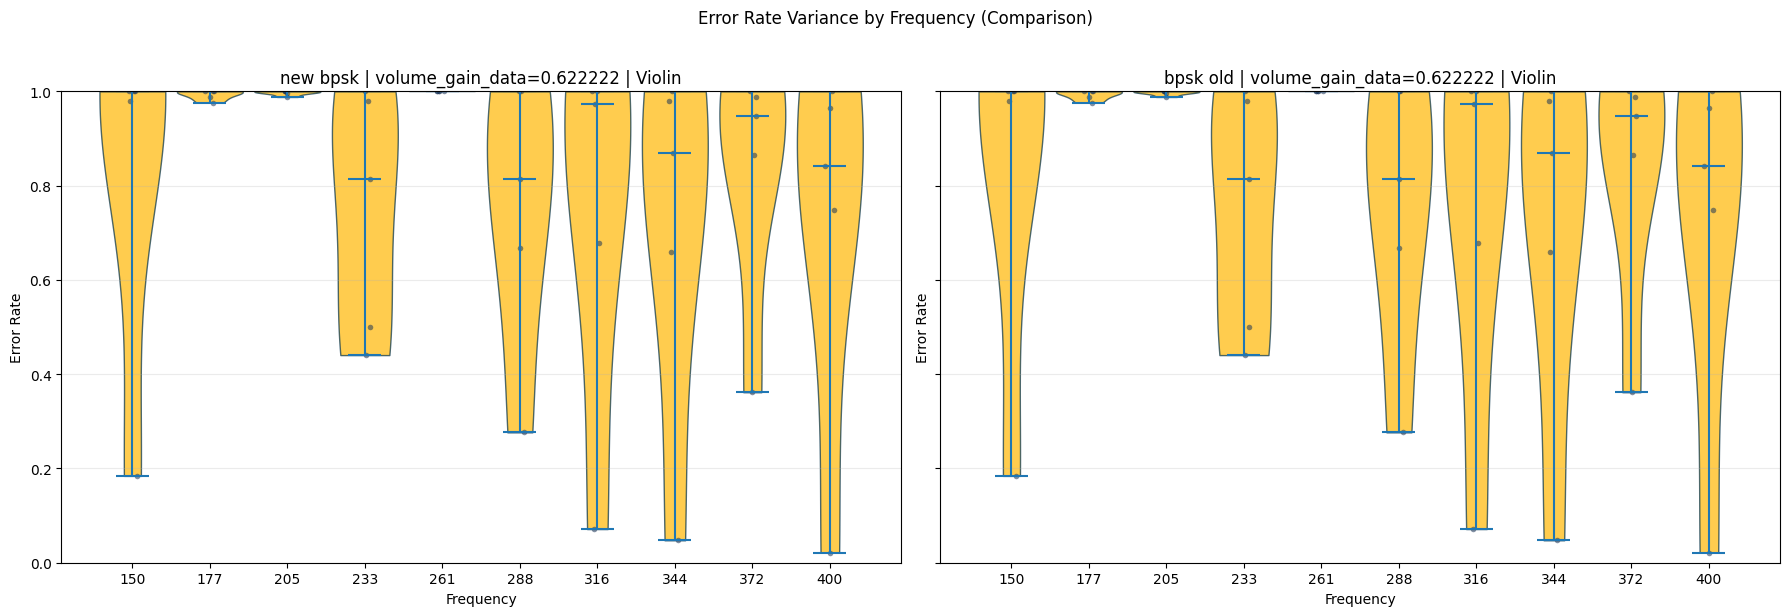

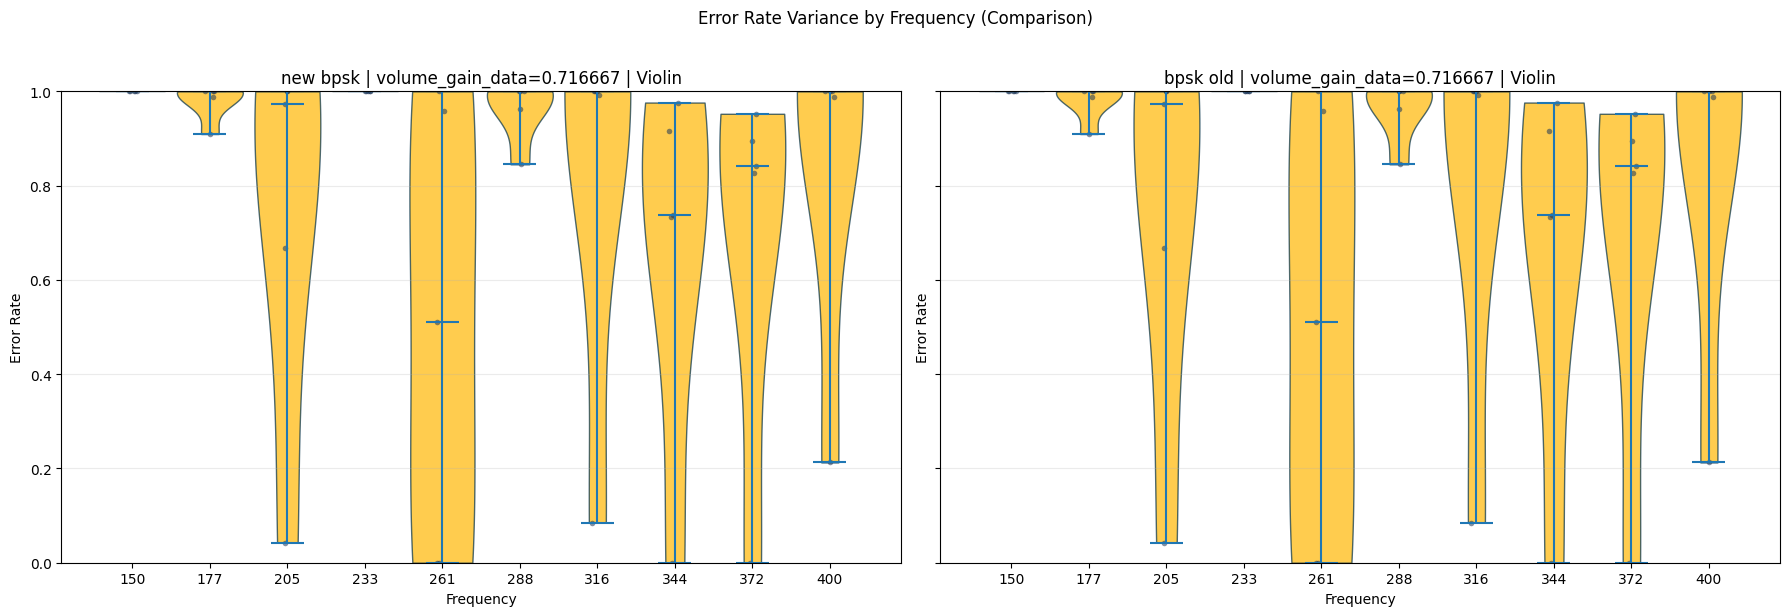

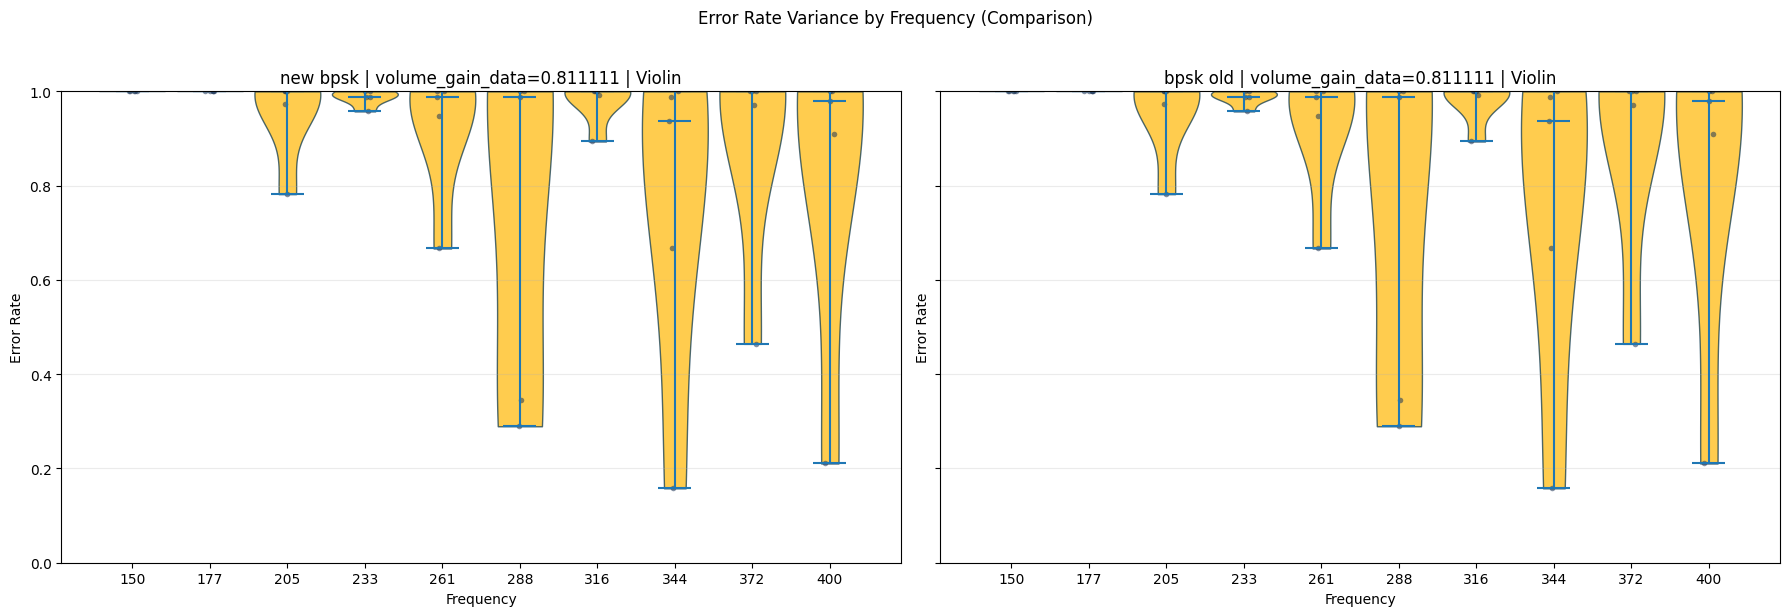

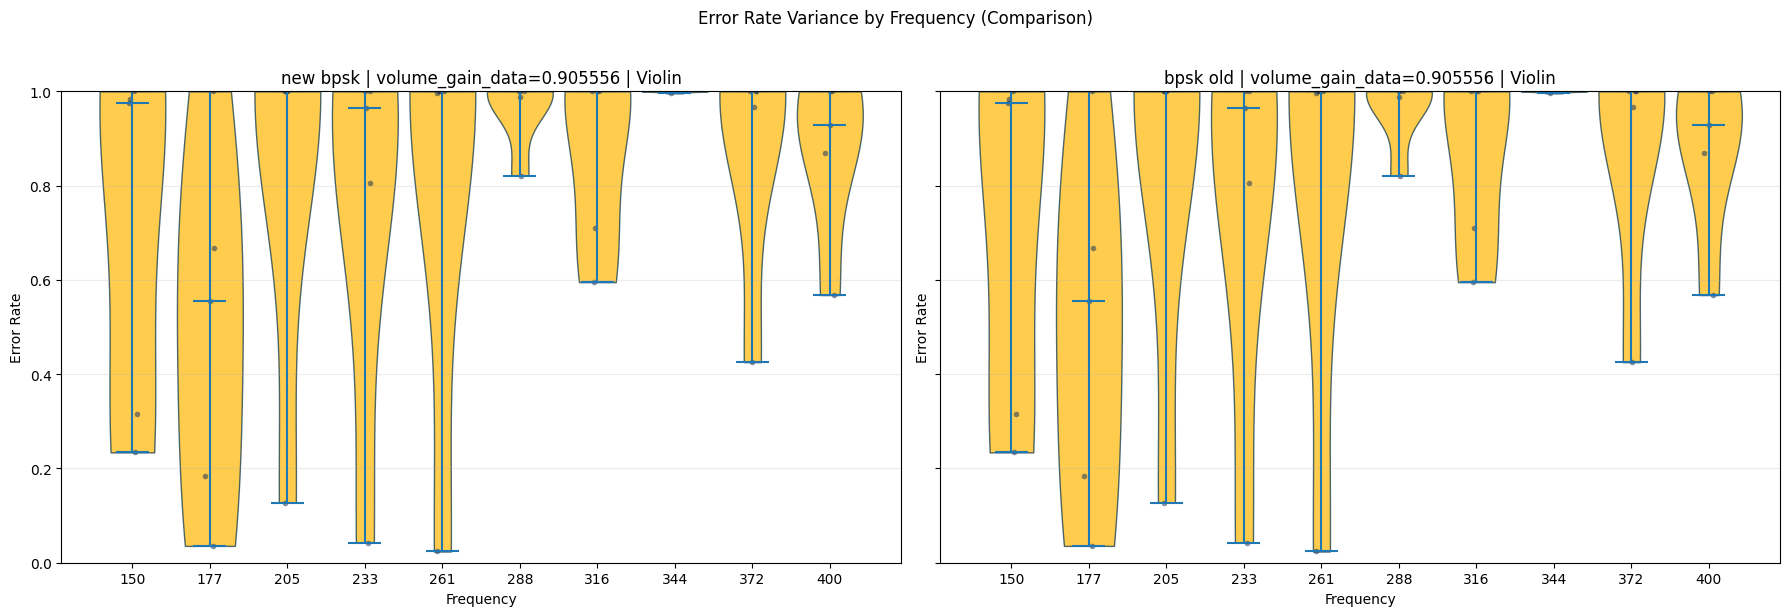

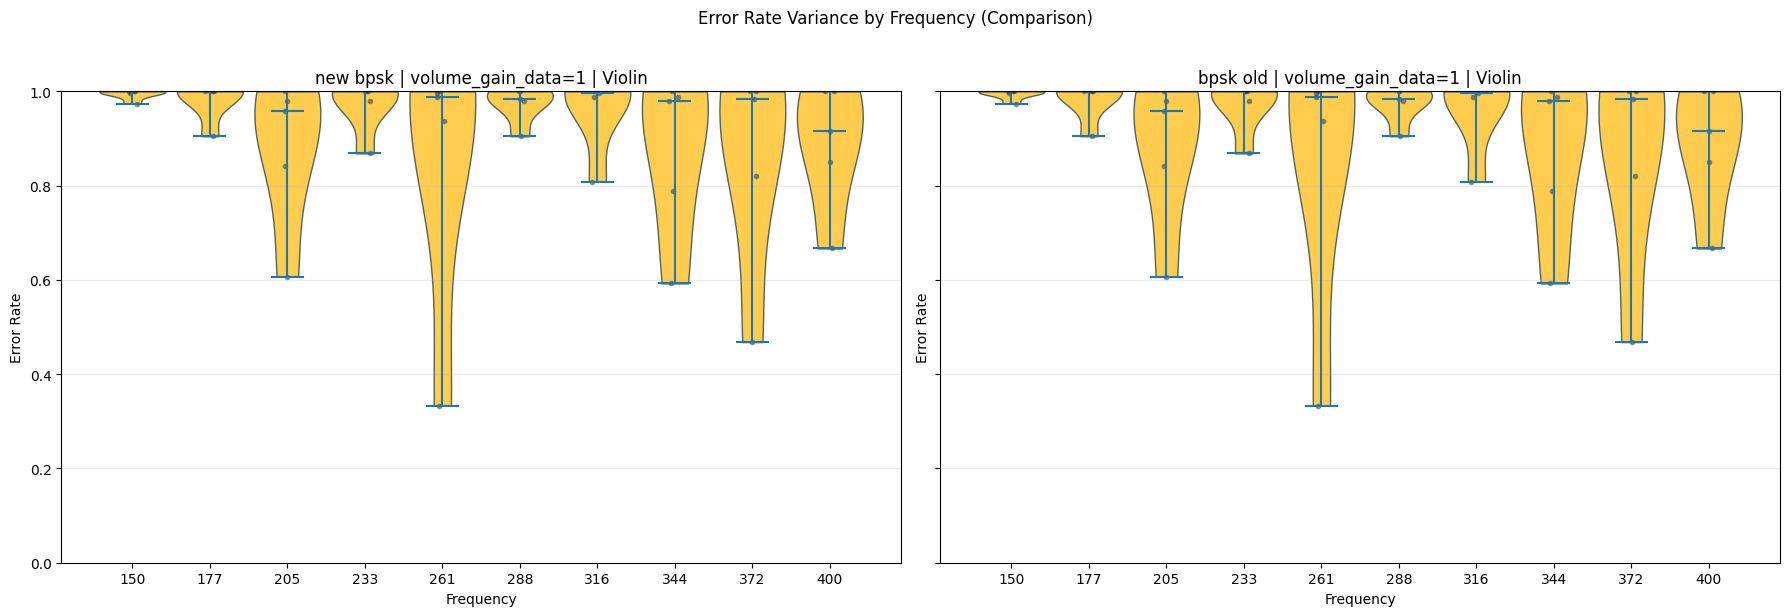

In [26]:
from plot_helpers import plot_error_rate_variance_for_all_volume_gains_comparison

plot_error_rate_variance_for_all_volume_gains_comparison(
    df_first,
    df_second,
    label_a=LABEL_FIRST,
    label_b=LABEL_SECOND,
    prefer_box_if_sparse=True,
    min_points_per_group=5,
)

## 3D Static Render (Non-interactive)
This adds a static 3D view of the same comparison data without changing the interactive Plotly figure above.

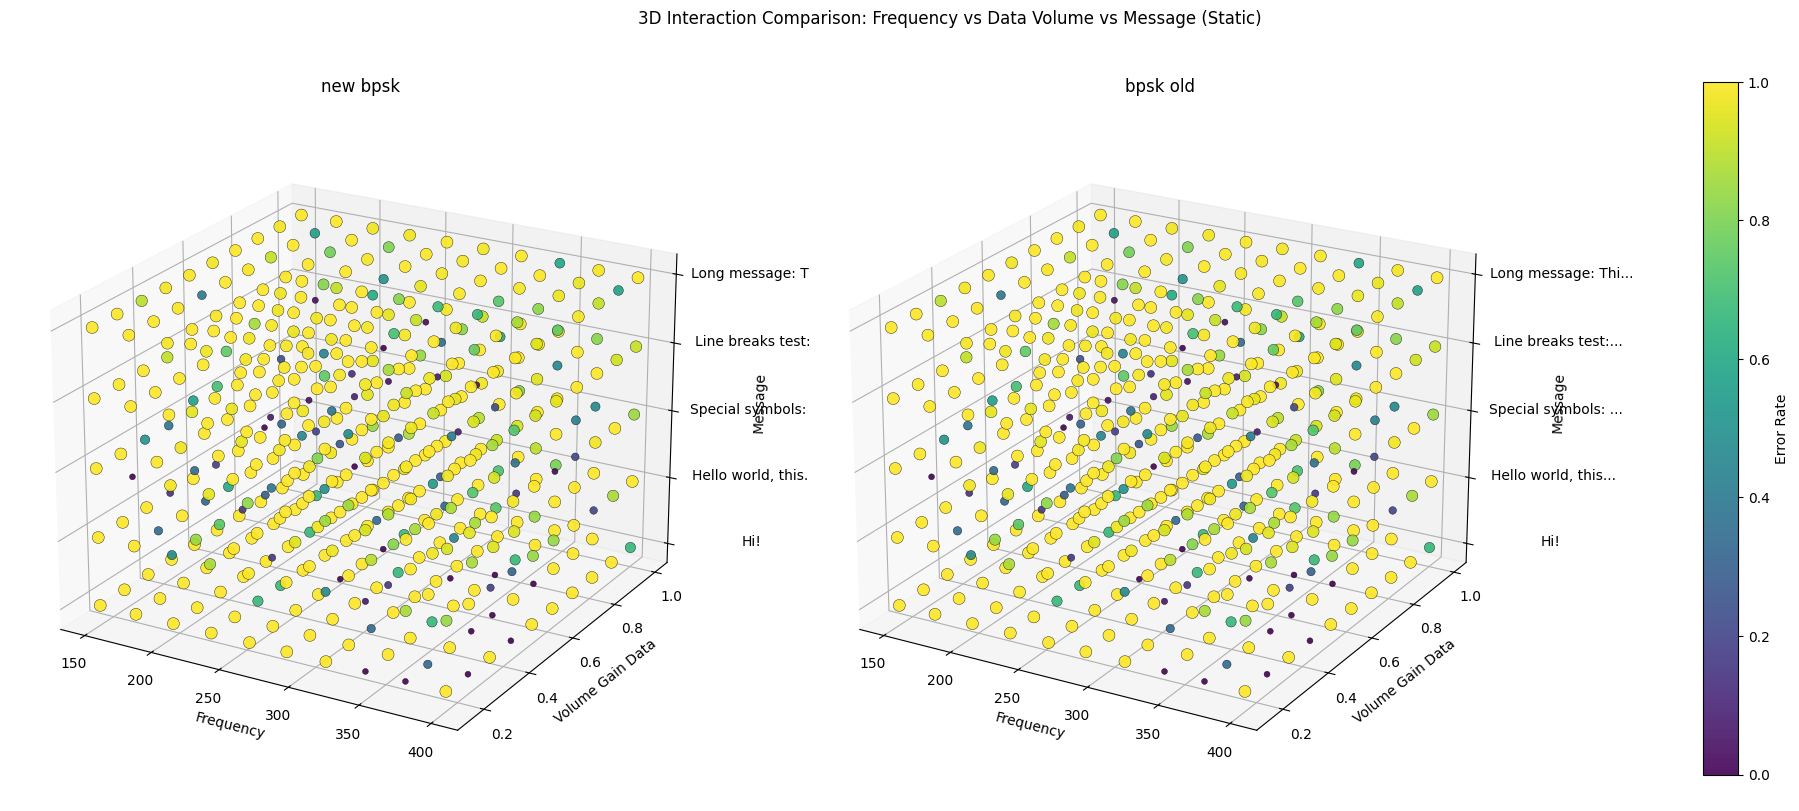

In [27]:
from plot_helpers import plot_static_3d_interaction_comparison

plot_static_3d_interaction_comparison(
    df_first,
    df_second,
    label_a=LABEL_FIRST,
    label_b=LABEL_SECOND,
)

## 3D Interaction: Frequency, Data Volume, and Message (Comparison)
This figure is split into two 3D panels:
- Column A: `csv_path` (actual pipeline output)
- Column B: `no_audio_compression` (best-case reference)
Color and marker size encode `error_rate` (lower is better).

In [28]:
from plot_helpers import plot_3d_interaction_comparison

plot_3d_interaction_comparison(
    df_first,
    df_second,
    label_a=LABEL_FIRST,
    label_b=LABEL_SECOND,
)